In [1]:
import matplotlib.pyplot as plt

import hypernetx as hnx
from hypernetx.algorithms import temporal

# Temporal Hypergraph Paths
(or the easiest/fastest way to ditch Fluffy)

This tutorial explores the use of temporal hypergraph shortest paths. The notebook is motivated by Alice seeking to find pet care for her beloved cat, Fluffy so that Alice can take an extended vacation. Alice and her friends have a strict schedule for the week that is known/planned ahead for the week. None of them are willing to deviate from their schedule and simply pick up Fluffy from Alice or each other. Instead, Alice must try to find a way to get Fluffy to Bob (who has agreed to care for Fluffy long term) by handing off Fluffy from friend to friend until Fluffy reaches Bob.

Alice wants to consder two possible types of solutions:
1. The *shortest path*: how to get Fluffly to Bob with the *fewest car trips* (because riding in the car is very stressful for Fluffy), and
2. The *quickest path*: how to get Fluffy to Bob the *soonest* (because Alice can only leave for Vacation once Fluffy is safely at home with Bob)

We consider a hypergraph *H* where the nodes consist of Alice together with her friends and the hyper edges consist of the events where Alice or any of her friends are co-located. This hypergraph is constructed below. For simplicity, one event occurs per week day, events (hyper edges) are numbered 0 - 5, and each event is at a different location. We assume that handing off Fluffy to a friend at an event will count as two car trips (one to take Fluffy from to the event, and one to bring Fluffy back).

In [2]:
events = {
    0: ['Chad', 'Alice'],
    1: ['Alice', 'Erin'],
    2: ['Devon', 'Chad'],
    3: ['Erin', 'Devon'],
    4: ['Bob', 'Erin', 'Devon'],
    5: ['Alice', 'Bob'],
}

# desccriptions useful for visualizaiton, but not necessary for solution
event_names = [
    'Work\nMon',
    'Gym\nTue',
    'Store\nWed',
    'Park\nThu',
    'Party\nFri',
    'Brunch\nSat',
]

edge_order = sorted(events)

H = hnx.Hypergraph(events)

## Solutions
The example below computes both solutions. It relies on `hypernetx.algorithms.temporal.temporal_shortest_path` to compute each solution. Then the hypergraph is visualized as a storyline using `hypernetx.draw_incidence_storyline` and the path is highlighted using `hypernetx.algorithms.temporal.encode_path`. We will discuss the definitions and details of the solution further on in the notebook.

### Storyline visualization for temporal hypergraphs
The storyline visualizations are intended for drawing edge-ordered hypergraphs, like we have in our scenario. Because these visualizations can also encode data onto the incidences and segments, they are ideal for explaining the solutions to our temporal hypergraph shortest path problem. In these visualizations, nodes are drawn as thin horizontal lines and hyper edges are drawn as thick vertical rounded rectangles. Each edge is assigned a unique x-coordinate as defined by the edge order provided to the visualization. Incidences are drawn as circles where the line for a node and an edge intersect.

The y-coordinates of nodes are optimized to reduce the clutter in the visualization such as unnecessary node bends, node-node and node-edge crossings. A node may cross an edge in the drawing even if that node is not a member of that edge. In this case, no circle is drawn at that location because that incidence is not in the hypergraph. Nodes are allowed to bend, and more than one node may occupy the same y-coordinate at different times.

### Encoding the optimal path in the visualization

Temporal hypergraph paths are shown using the storyline visualization as well. The starting and ending incidence of the path is filled with red, and the intermediate nodes are filled with black (the remaining nodes are not filled/white). The node portion of the path is thicker, and the edge portion of the path is filled with lightgray.

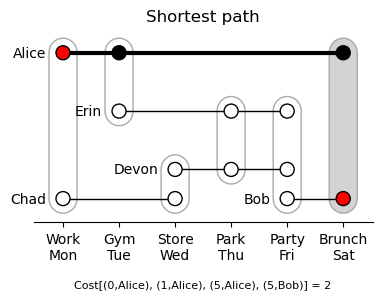

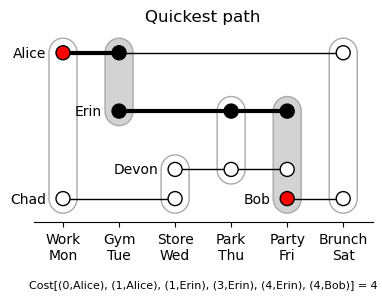

In [3]:
def path_str(cost, path):
    p = ', '.join([
        f'({e},{v})'
        for e, v in path
    ])
    
    return f'\nCost[{p}] = {cost}'

                   
def solve_and_draw_path(H, edge_order, source, target, edge_labels=None, title=None, show_path=True, **kwargs):
    plt.figure()
    ax = plt.gca()

    cost, path = temporal.temporal_shortest_path(
        H, source, target,
        edge_order=edge_order,
        **kwargs,
    )

    hnx.draw_incidence_storyline(
        H,
        edge_order=edge_order,
        edge_labels=edge_labels,
        layout_kwargs=dict(allow_edge_crossings=False),
        auto_size=1.25,
        **temporal.encode_path(path)
    )

    if title:
        plt.title(f'{title}')

    if show_path:
        plt.xlabel(path_str(cost, path), fontsize=8)
        
    return cost, path

kwargs = dict(
    H=H,
    edge_order=edge_order,
    source=(0, 'Alice'),
    target='Bob',
    edge_labels=event_names
)

cost, path = solve_and_draw_path(
    title='Shortest path',
    method='short',
    **kwargs
)

cost, path = solve_and_draw_path(
    title='Quickest path',
    method='quick',
    **kwargs
)

### Discussion of competing solutions
This reveals two different solutions for Alice:
1. The shortest path has Alice keeping Fluffy until Brunch on Saturday, where she gives Fluffy to Bob. This has a cost of 1 handoff but requires 5 days.
2. The quickest path has Alice giving Fluffy to Erin at the Gym on Tuesday, then Erin giving Fluffy to Bob at the Party on Friday. This a cost of 4 days, but requires 2 handoffs.


## Details
First, let's take a look at how the path is modeled. We'll print out the path that was found above for solution #2.

In [4]:
path

[(0, 'Alice'), (1, 'Alice'), (1, 'Erin'), (3, 'Erin'), (4, 'Erin'), (4, 'Bob')]

### Definitions
We have chosen to represent the hypergraph path as a sequence of tuples. Each tuple represents an incidence *(e, v)*, i.e. the vertex *v* is a member of the hyper edge *e*. The `temporal_shortest_path` algorithm outputs sequences that are both **feasible** and **proper**.
* A **feasible path** is a path where every tuple is an incidence in *H* and the tuples are ordered by the given edge order. Additionally, adjacent tuples can differ by only the hyper edge or the node in the incidence, but not both.
* A **proper path** is a feasible path with no omitted incidences, i.e. if *(i, v)* and *(j, v)* are adjacent in the path, then *(k, v)* does not exist where *i < k < j*. Additionally proper paths have no repeated incidences.

For example, the path above is proper. However, it would not be feasible if the incidence *(1, Erin)* was dropped. The path would not be proper if the incidence *(3, Erin)* was dropped. To further illustrate the concept, the code below demonstrates how to check for feasible and proper paths.

In [5]:
# use soft_assert instead of native python assert so the notebook will run
def soft_assert(condition, message):
    if not condition:
        print(message)
        
def assert_feasible(H, path, key=None):

    if key is None:
        key = lambda e: e

    for e, v in path:
        soft_assert(
            e in H.edges and v in H.edges[e],
            f'path is infeasible by definition: {v} is not a member of {{{e}: {H.edges[e]}}}'
        )

    for (e1, v1), (e2, v2) in zip(path[:-1], path[1:]):
        soft_assert(
            key(e1) <= key(e2),
            f'path is infeasible due to ordering: ({e1},{v1}) and ({e2},{v2}) are adjacent but {e1} > {e2}'
        )
        soft_assert(
            e1 == e2 or v1 == v2,
            f'path is infeasible due to reachability: ({e1},{v1}) and ({e2},{v2}) do not share a node or hyper edge'
        )
        

def assert_proper(H, path, key=None):
    if key is None:
        key = lambda e: e

    assert_feasible(H, path)

    for (e1, v1), (e2, v2) in zip(path[:-1], path[1:]):
        if v1 == v2:
            v = v1
            for e in H.nodes[v]:
                if e != e1 and e != e2:
                    soft_assert(
                        key(e) < key(e1) or key(e2) < key(e),
                        f'path is improper due to missing incidence: found ({e},{v}) in H which is between ({e1},{v}) and ({e2},{v}) but not in the path'
                    )
                    
# test the path returned by the shortest path algorith--should pass
assert_feasible(H, path)
assert_proper(H, path)

In [6]:
# the cases below should fail

# included (0, Erin), which is not in H
assert_feasible(H, [(0, 'Erin'), (1, 'Erin'), (4, 'Erin'), (4, 'Bob')])

# added (1, Alice) to beginning
assert_feasible(H, [(1, 'Alice'), (0, 'Alice'), (1, 'Alice'), (1, 'Erin'), (4, 'Erin'), (4, 'Bob')])

# dropped (1, Alice)
assert_feasible(H, [(0, 'Alice'), (1, 'Erin'), (4, 'Erin'), (4, 'Bob')])

# dropped (3, Erin)
assert_proper(H, [(0, 'Alice'), (1, 'Alice'), (1, 'Erin'), (4, 'Erin'), (4, 'Bob')])

path is infeasible by definition: Erin is not a member of {0: ['Chad', 'Alice']}
path is infeasible due to ordering: (1,Alice) and (0,Alice) are adjacent but 1 > 0
path is infeasible due to reachability: (0,Alice) and (1,Erin) do not share a node or hyper edge
path is improper due to missing incidence: found (3,Erin) in H which is between (1,Erin) and (4,Erin) but not in the path


### Algorithm
We solve the temporal hypergraph shortest path problem by first constructing a directed graph *G=(V, E)* such that any path in *G* yields a feasible and proper path in *H*.
* The nodes in *G* consist of all the incidences in *H* together with the edges in *H*.
* A directed edge is added between each incidence and each edge containing that incidence (and vice versa)
* A directed edge is added between each pair of temporally adjacent incidences with the same node

This graph can be weighted in different ways:
1. The weight between an incidence and a hyper edge is set to *1* when solving for **short paths** and *0* otherwise, and
2. The weight between two incidences is set to their time difference when solving for **quick paths** and *0* otherwise.

Once the weighted directed graph is created, then any shortest path solver can be useed to find the shortest path between a given set of endpoints. The figure below shows this graph for our working example weighted both ways and includes the shortes path solution for each case. We reuse the same color scheme as found in the storyline visualization above, e.g. endpoints are red, and hyper edges & incidences along the solution are filled in.

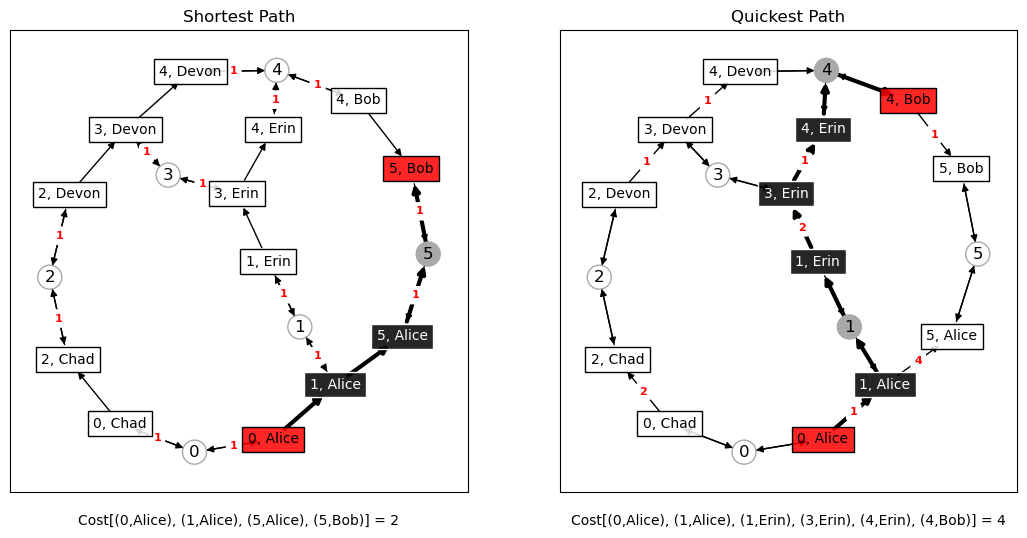

In [7]:
args = H, (0, 'Alice'), 'Bob'
kwargs = dict(
    edge_order=edge_order,
    return_graph=True
)

plt.figure(figsize=(13, 6))

plt.subplot(121)
cost, path, G = temporal.temporal_shortest_path(
    *args, **kwargs, method='short',
)
temporal.draw_temporal_incidence_graph(G, path=path)
plt.title('Shortest Path')
plt.xlabel(path_str(cost, path))

plt.subplot(122)
cost, path, G = temporal.temporal_shortest_path(
    *args, **kwargs, method='quick',
)
temporal.draw_temporal_incidence_graph(G, path=path)
plt.title('Quickest Path')
plt.xlabel(path_str(cost, path));

## Flexible Path Endpoints
In the above example we specified the endpoints as *(0, Alice)* and *Bob* forcing the algorithm to start with *Alice* at edge *0* but end with any incidence with *Bob*. The `temporal_shortest_path` function allows endpoints to be flexibly specified as *incidences*, *nodes*, or *hyper edges*. The function will always return a sequence of incidences, but the shortest path algorithm will consider all incidences related to a node or edge.

Below are some examples with combinations of endpoint types of endpoints not yet explored. Note that when an *edge* is specified as an endpoint, for example, the algoirthm chooses which *incidence* to start with, so there is no cost considered between that edge and that incidence. This is seen in the first example where the algorithm is specified to start with edge *0*, and chooses a path that starts with *(0, Chad)*.

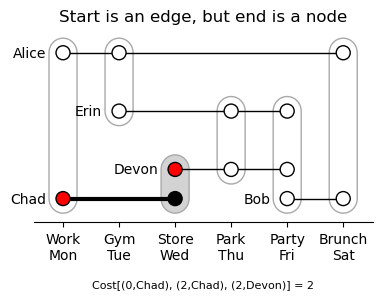

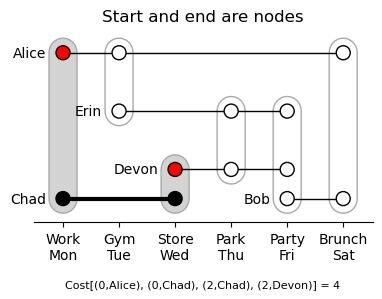

In [8]:
kwargs = dict(
    H=H,
    edge_order=edge_order,
    edge_labels=event_names,
    method='short'
)

solve_and_draw_path(
    source=0,
    target='Devon',
    title='Start is an edge, but end is a node',
    **kwargs
)

solve_and_draw_path(
    source='Alice',
    target='Devon',
    title='Start and end are nodes',
    **kwargs
);

# Comparison with Alternatives Approaches
Could alternative approaches have worked for this use case, and if so, what are the advantages or disadvantages?

The **bipartite graph** representation of the hypergraph `hypernetx.Hypergraph.bipartite` is a good starting place. However, there is no edge weighting scheme or directing scheme that will allow paths to respect the temporal ordering on edges. In other words, if a path moves from an edge to a node, there is no way to guarantee the next move back to an edge does not violate the temporal ordering. A solution would be to implement a modified version of the shortest path solver that maintains a clock to address this.

The **line graph** representation of the hypergraph `hypernetx.Hypergraph.get_line_graph` is suitable for the *quickest path* use case, but has some significant drawbacks as well. The line graph is a graph representation of the overlap between all pairs of hyper edges. In other words, if two edges in the hypergraph share a vertex, then there is an edge between those two hyper edges in the line graph. We can direct the edges in the line graph so that the direction respects the temporal ordering of the hyper edges. The cell below illustrates this concept, where we have overlaid the relevant part of the solutions, i.e., the incidence path, we previously found on the line graph representation.

## Quickest Paths
To find the *quickest path*, we can solve for the shortest path on the line graph when the weights are set to the time differences between hyper edges. Not representing nodes in the line graph is acceptable for this use case because there is no cost incurred for moving between nodes. Posession of *Fluffy* could be inferred from the solution this case.

However, using the line graph this way could have computational drawbacks. The number of edges in the line graph is $O(|E|^2)$ in the worst case, whereas the number of edges in the temporal hypergraph representation is twice the number of incidences, which is $O(|V|\cdot|E|)$ in the worst case. In practial applications we often find that $|V|$ < $|E|$ and/or the original hypergraph is sparse, so that the number of incidences is typically much less than the number of edges in the line graph.

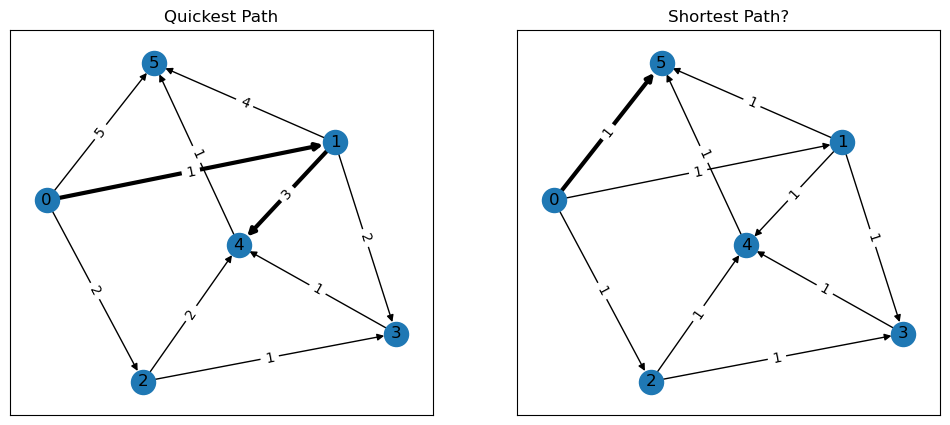

In [9]:
from importlib import reload; reload(temporal)

plt.figure(figsize=(12, 5))

plt.subplot(121)
plt.title('Quickest Path')
pos = temporal.draw_temporal_line_graph(
    temporal.create_temporal_line_graph(H, edge_order),
    path=[0, 1, 4],
)

plt.subplot(122)
plt.title('Shortest Path?')
temporal.draw_temporal_line_graph(
    temporal.create_temporal_line_graph(H, edge_order, weight_by_time=False),
    path=[0, 5],
    pos=pos,
);

## Shortest Paths
To find the *shortest path* in the temporal hypergraph, it is unclear how weights should be assigned. Recall that the purpose of the weighting in this use case was to assign a cost to moving between nodes in the hypergraph, i.e. transferring posession of *Fluffy* from one person to another. But the line graph does not directly represent the nodes from the original hyper graph, so we don't know whether the weight should be 0 or 1 for a given edge in the line graph. In other words, this approach doesn't distinguish between *[(0, Alice), (1, Alice)]* versus *[(0, Alice), (1, Alice), (1, Erin)]*. Both of these paths would be represented as $[0, 1]$ in the line graph.

Furthermore, we could introduce custom edge weights between nodes and hyper edges. In our use case, this could represent the cost of transporting *Fluffy* to a particular event/location from a person's home. This would be useful, for example, if we wish to minimize the total amount of time *Fluffy* spends in transit, and there are significant differences in transit times to events.

The example below illustrates a version of our use case where we assign coordinates to both people (nodes) and events (hyper edges). The temporal hypergraph is weighted based on the euclidean distance between the person and the event. The scenario is designed so that an obvious shorter path lies close to diagonal on the map between Alice and Bob. This path, will be selected by the shorsest path algorithm even though it contains more hops than the origional solution, which would would have a much higher weight due to the placement of "Brunch" at the corner of the map.

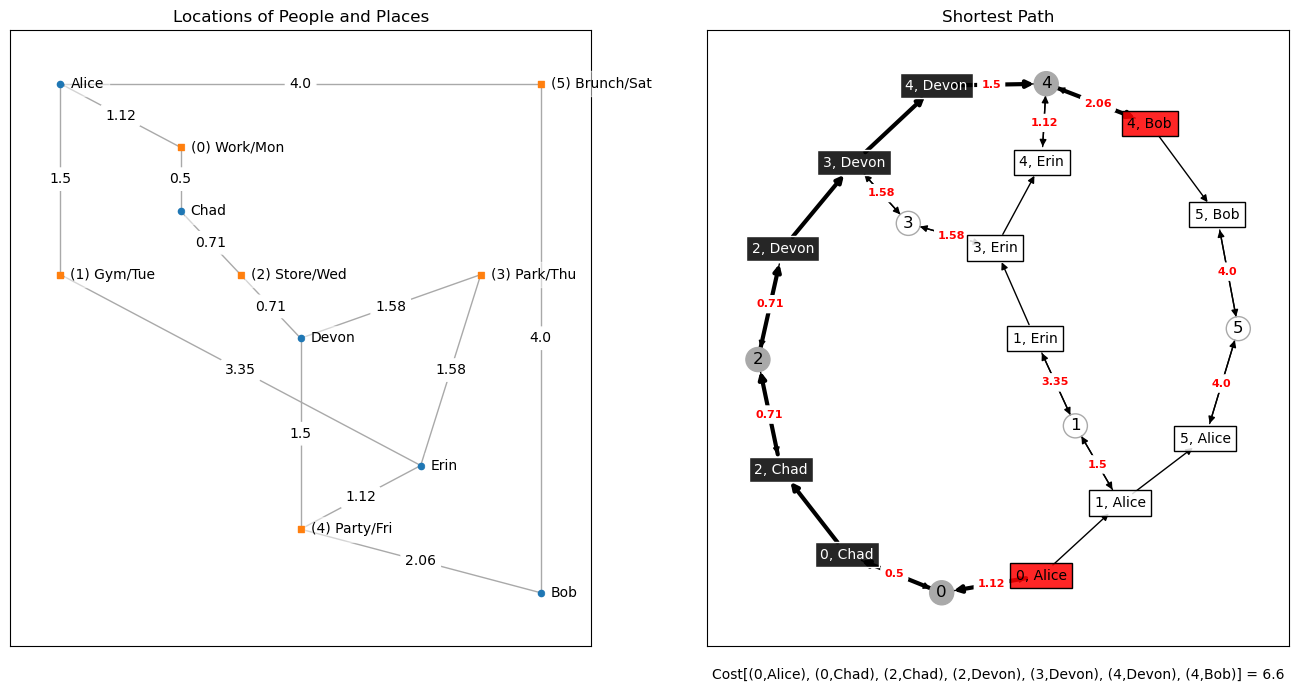

In [10]:
import networkx as nx
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist

plt.figure(figsize=(16.5, 8))

xy_people = pd.DataFrame({
    'Alice': [0, 4],
    'Bob': [4, 0], 
    'Chad': [1, 3],
    'Devon': [2, 2],
    'Erin': [3, 1]
}).T

xy_events = pd.DataFrame({
    0: [1, 3.5], # work
    1: [0, 2.5], # gym
    2: [1.5, 2.5], # store
    3: [3.5, 2.5], # park
    4: [2, 0.5], # party
    5: [4, 4] # brunch
}).T

D = pd.DataFrame(
    cdist(xy_events, xy_people, metric='euclidean'),
    index=xy_events.index,
    columns=xy_people.index
).round(2)

ax = plt.subplot(121)

# draw the incidences (links between people and places)
G = H.bipartite()
pos = pd.concat((xy_people, xy_events)).apply(list, axis=1).to_dict()

nx.draw_networkx_edges(
    G, pos,
    edge_color='darkgray'
)

# annoate edges with distance
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels={e: D.loc[e] for e in G.edges()},
    rotate=False
)

# draw the marks and labels for peole
text_kwargs = dict(
    va='center',
    xytext=(10, 0),
    textcoords='offset pixels',
    backgroundcolor=(1, 1, 1, .5)
)
xy_people.plot.scatter(0, 1, ax=ax)
for s, xy in xy_people.iterrows():
    ax.annotate(s, xy, **text_kwargs)

#draw the marks and labels for places
xy_events.plot.scatter(0, 1, color=plt.cm.tab10(1), marker='s', ax=ax)
for i, xy in xy_events.iterrows():
    s = f'({i}) ' + event_names[i].replace('\n', '/')
    ax.annotate(s, xy, **text_kwargs)

plt.xlabel('')
plt.ylabel('')
plt.title('Locations of People and Places')

# pass in a custom weight function that uses the distance between people and events
def custom_weight_method(u, v):
    if u in D.index: # hyperedge -> incidence
        return D.loc[u, v[1]]
    elif v in D.index: # incidence -> hyper edge
        return D.loc[v, u[1]]
    return 0 # incidence -> incidence
    
cost, path, G = temporal.temporal_shortest_path(
    H, (0, 'Alice'), 'Bob',
    method=custom_weight_method,
    edge_order=edge_order,
    return_graph=True
)

ax = plt.subplot(122)

temporal.draw_temporal_incidence_graph(G, path=path)
plt.title('Shortest Path')
plt.xlabel(path_str(cost, path));